# 🌪️ NLP Disaster Tweets — EDA & Error Analysis

> **Kaggle Competition**: [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started)  
> **Task**: 트윗이 실제 재난을 묘사하는지 이진 분류 (1 = 재난, 0 = 비재난)  
> **Model**: RoBERTa (K-Fold OOF 기반 에러 분석 포함)

---

## 📋 목차
1. [환경 설정 & 데이터 로드](#1)
2. [기초 탐색 (EDA)](#2)
3. [메타 특징 분석](#3)
4. [타깃 분포 & N-gram 분석](#4)
5. [OOF 에러 분석 (RoBERTa)](#5)


## 1. 환경 설정 & 데이터 로드 <a id='1'></a>

In [1]:
# 필요 패키지 설치 (Colab 환경)
!pip install transformers datasets wordcloud -q


In [2]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from wordcloud import STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# 시각화 스타일
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100


In [3]:
# Google Drive 마운트 (Colab 환경)
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/JM/ai-스터디/transformer/nlp-Disaster_Tweets-kaggle'
os.chdir(BASE_PATH)
print('작업 경로:', os.getcwd())


Mounted at /content/drive
작업 경로: /content/drive/MyDrive/JM/ai-스터디/transformer/nlp-Disaster_Tweets-kaggle


In [4]:
# 데이터 로드
train_df = pd.read_csv(BASE_PATH + '/nlp-getting-started/train.csv')
test_df  = pd.read_csv(BASE_PATH + '/nlp-getting-started/test.csv')

# 결측치 처리
train_df['text'] = train_df['text'].fillna('')
test_df['text']  = test_df['text'].fillna('')

print(f'Train: {train_df.shape} | Test: {test_df.shape}')


Train: (7613, 5) | Test: (3263, 4)


## 2. 기초 탐색 (EDA) <a id='2'></a>

In [5]:
# 데이터 샘플 확인
train_df.head()


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [6]:
# 기본 정보
print('=== Train Info ===')
print(f'  행: {len(train_df):,} | 열: {train_df.shape[1]}')
print(f'  결측치:\n{train_df.isnull().sum()}')
print(f'\n=== Test Info ===')
print(f'  행: {len(test_df):,} | 열: {test_df.shape[1]}')


=== Train Info ===
  행: 7,613 | 열: 5
  결측치:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

=== Test Info ===
  행: 3,263 | 열: 4


## 3. 메타 특징 분석 <a id='3'></a>

재난 트윗은 주로 뉴스 기관이 작성하므로 **더 공식적인 문체, 긴 단어, 적은 오타** 등의 패턴이 나타납니다.  
아래 9가지 메타 특징을 추출하여 클래스 간 분포 차이를 확인합니다.

| 특징 | 설명 |
|------|------|
| `word_count` | 단어 수 |
| `unique_word_count` | 고유 단어 수 |
| `stop_word_count` | 불용어 수 |
| `url_count` | URL 수 |
| `mean_word_length` | 평균 단어 길이 |
| `char_count` | 전체 문자 수 |
| `punctuation_count` | 문장 부호 수 |
| `hashtag_count` | 해시태그(`#`) 수 |
| `mention_count` | 멘션(`@`) 수 |


In [7]:
def add_meta_features(df: pd.DataFrame) -> pd.DataFrame:
    """텍스트 메타 특징을 DataFrame에 추가합니다."""
    text = df['text'].astype(str)

    df['word_count']        = text.apply(lambda x: len(x.split()))
    df['unique_word_count'] = text.apply(lambda x: len(set(x.split())))
    df['stop_word_count']   = text.apply(lambda x: sum(w.lower() in STOPWORDS for w in x.split()))
    df['url_count']         = text.apply(lambda x: sum('http' in w for w in x.lower().split()))
    df['mean_word_length']  = text.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df['char_count']        = text.apply(len)
    df['punctuation_count'] = text.apply(lambda x: sum(c in string.punctuation for c in x))
    df['hashtag_count']     = text.apply(lambda x: x.count('#'))
    df['mention_count']     = text.apply(lambda x: x.count('@'))
    return df

train_df = add_meta_features(train_df)
test_df  = add_meta_features(test_df)

print('메타 특징 추가 완료')
train_df[['word_count','unique_word_count','char_count','hashtag_count','mention_count']].describe().round(2)


메타 특징 추가 완료


,word_count,unique_word_count,char_count,hashtag_count,mention_count
count,7613.00,7613.00,7613.00,7613.00,7613.00
mean,14.90,14.34,101.04,0.45,0.36
std,5.73,5.28,33.78,1.10,0.72
min,1.00,1.00,7.00,0.00,0.00
25%,11.00,11.00,78.00,0.00,0.00
50%,15.00,14.00,107.00,0.00,0.00
75%,19.00,18.00,133.00,0.00,1.00
max,31.00,29.00,157.00,13.00,8.00


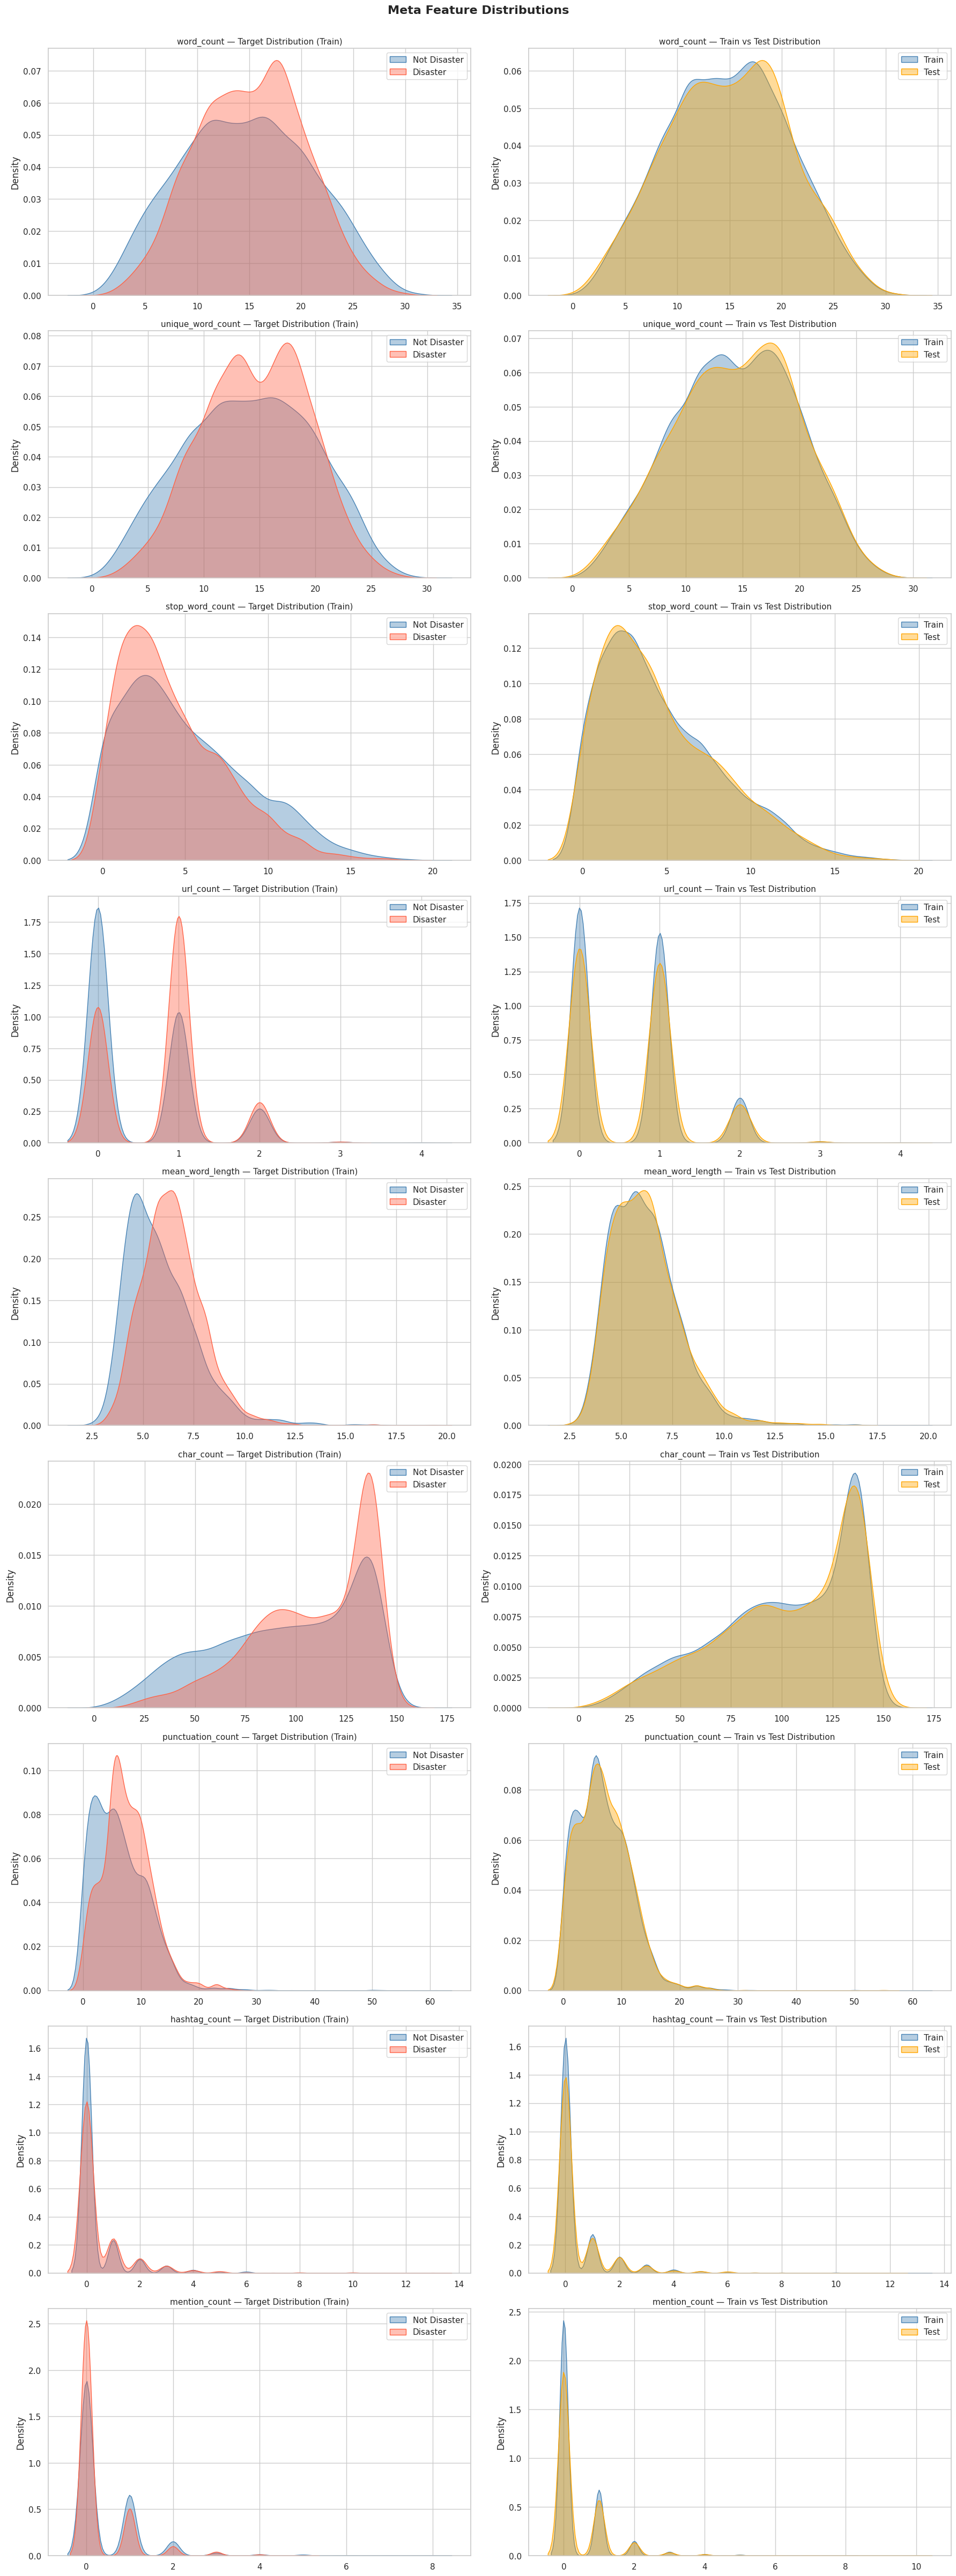

In [8]:
METAFEATURES   = ['word_count', 'unique_word_count', 'stop_word_count', 'url_count',
                   'mean_word_length', 'char_count', 'punctuation_count', 'hashtag_count', 'mention_count']
DISASTER_TWEETS = train_df['target'] == 1

fig, axes = plt.subplots(ncols=2, nrows=len(METAFEATURES), figsize=(18, 48))
fig.suptitle('Meta Feature Distributions', fontsize=16, fontweight='bold', y=1.001)

for i, feat in enumerate(METAFEATURES):
    # 클래스별 분포 (Train)
    sns.kdeplot(train_df.loc[~DISASTER_TWEETS, feat], label='Not Disaster', ax=axes[i][0], color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(train_df.loc[DISASTER_TWEETS,  feat], label='Disaster',     ax=axes[i][0], color='tomato',    fill=True, alpha=0.4)
    axes[i][0].set_title(f'{feat} — Target Distribution (Train)', fontsize=11)
    axes[i][0].legend()

    # Train vs Test 분포
    sns.kdeplot(train_df[feat], label='Train', ax=axes[i][1], color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(test_df[feat],  label='Test',  ax=axes[i][1], color='orange',    fill=True, alpha=0.4)
    axes[i][1].set_title(f'{feat} — Train vs Test Distribution', fontsize=11)
    axes[i][1].legend()

    for ax in axes[i]:
        ax.set_xlabel('')

plt.tight_layout()
plt.show()


**📌 주요 관찰:**
- 모든 메타 특징에서 Train/Test 분포가 매우 유사 → 분포 시프트 없음
- `word_count`, `unique_word_count`, `char_count`, `mean_word_length`, `punctuation_count`는 재난/비재난 간 유의미한 차이
- 재난 트윗이 전반적으로 더 길고 공식적인 언어를 사용하는 경향


## 4. 타깃 분포 & N-gram 분석 <a id='4'></a>

### 4.1 타깃 분포
클래스 불균형 수준을 확인합니다.  
Not Disaster(0): **57%** | Disaster(1): **43%** — 거의 균등하여 별도 stratification 불필요


/tmp/ipykernel_925/1563485146.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Disaster\n(4,342)', 'Disaster\n(3,271)'])


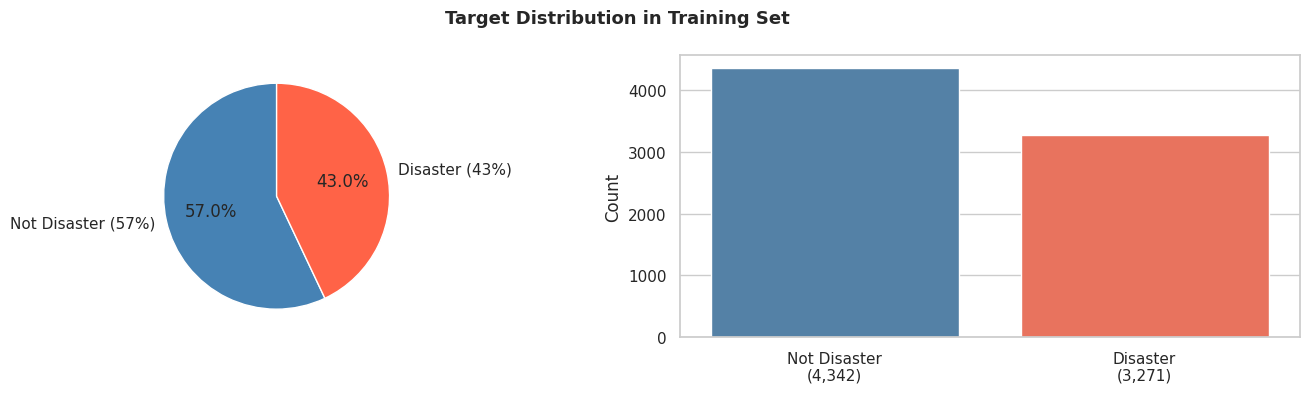

In [9]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
fig.suptitle('Target Distribution in Training Set', fontsize=13, fontweight='bold')

# Pie chart
train_df.groupby('target')['id'].count().plot(
    kind='pie', ax=axes[0],
    labels=['Not Disaster (57%)', 'Disaster (43%)'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_ylabel('')

# Count plot
sns.countplot(
    x=train_df['target'], hue=train_df['target'],
    palette=['steelblue', 'tomato'], ax=axes[1], legend=False
)
axes[1].set_xticklabels(['Not Disaster\n(4,342)', 'Disaster\n(3,271)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### 4.2 N-gram 분석
재난/비재난 트윗에서 자주 등장하는 단어 패턴을 Unigram · Bigram · Trigram으로 비교합니다.


In [10]:
def generate_ngrams(text: str, n_gram: int = 1) -> list:
    """텍스트에서 n-gram 리스트를 생성합니다 (불용어 제거)."""
    tokens = [t for t in text.lower().split() if t and t not in STOPWORDS]
    ngrams = zip(*[tokens[i:] for i in range(n_gram)])
    return [' '.join(ng) for ng in ngrams]


def build_ngram_df(tweets, n_gram: int) -> pd.DataFrame:
    """트윗 시리즈에서 n-gram 빈도 DataFrame을 반환합니다."""
    counter = defaultdict(int)
    for tweet in tweets:
        for ng in generate_ngrams(tweet, n_gram):
            counter[ng] += 1
    return pd.DataFrame(sorted(counter.items(), key=lambda x: x[1], reverse=True),
                        columns=['ngram', 'count'])


TOP_N = 20
disaster_tweets    = train_df.loc[DISASTER_TWEETS,  'text']
nondisaster_tweets = train_df.loc[~DISASTER_TWEETS, 'text']

ngram_data = {
    n: {
        'disaster':    build_ngram_df(disaster_tweets,    n),
        'nondisaster': build_ngram_df(nondisaster_tweets, n),
    }
    for n in [1, 2, 3]
}

print('N-gram 생성 완료')
ngram_data[1]['disaster'].head()


N-gram 생성 완료


,ngram,count
0,-,389
1,fire,151
2,via,117
3,...,106
4,&amp;,105


/tmp/ipykernel_925/1672418798.py:16: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


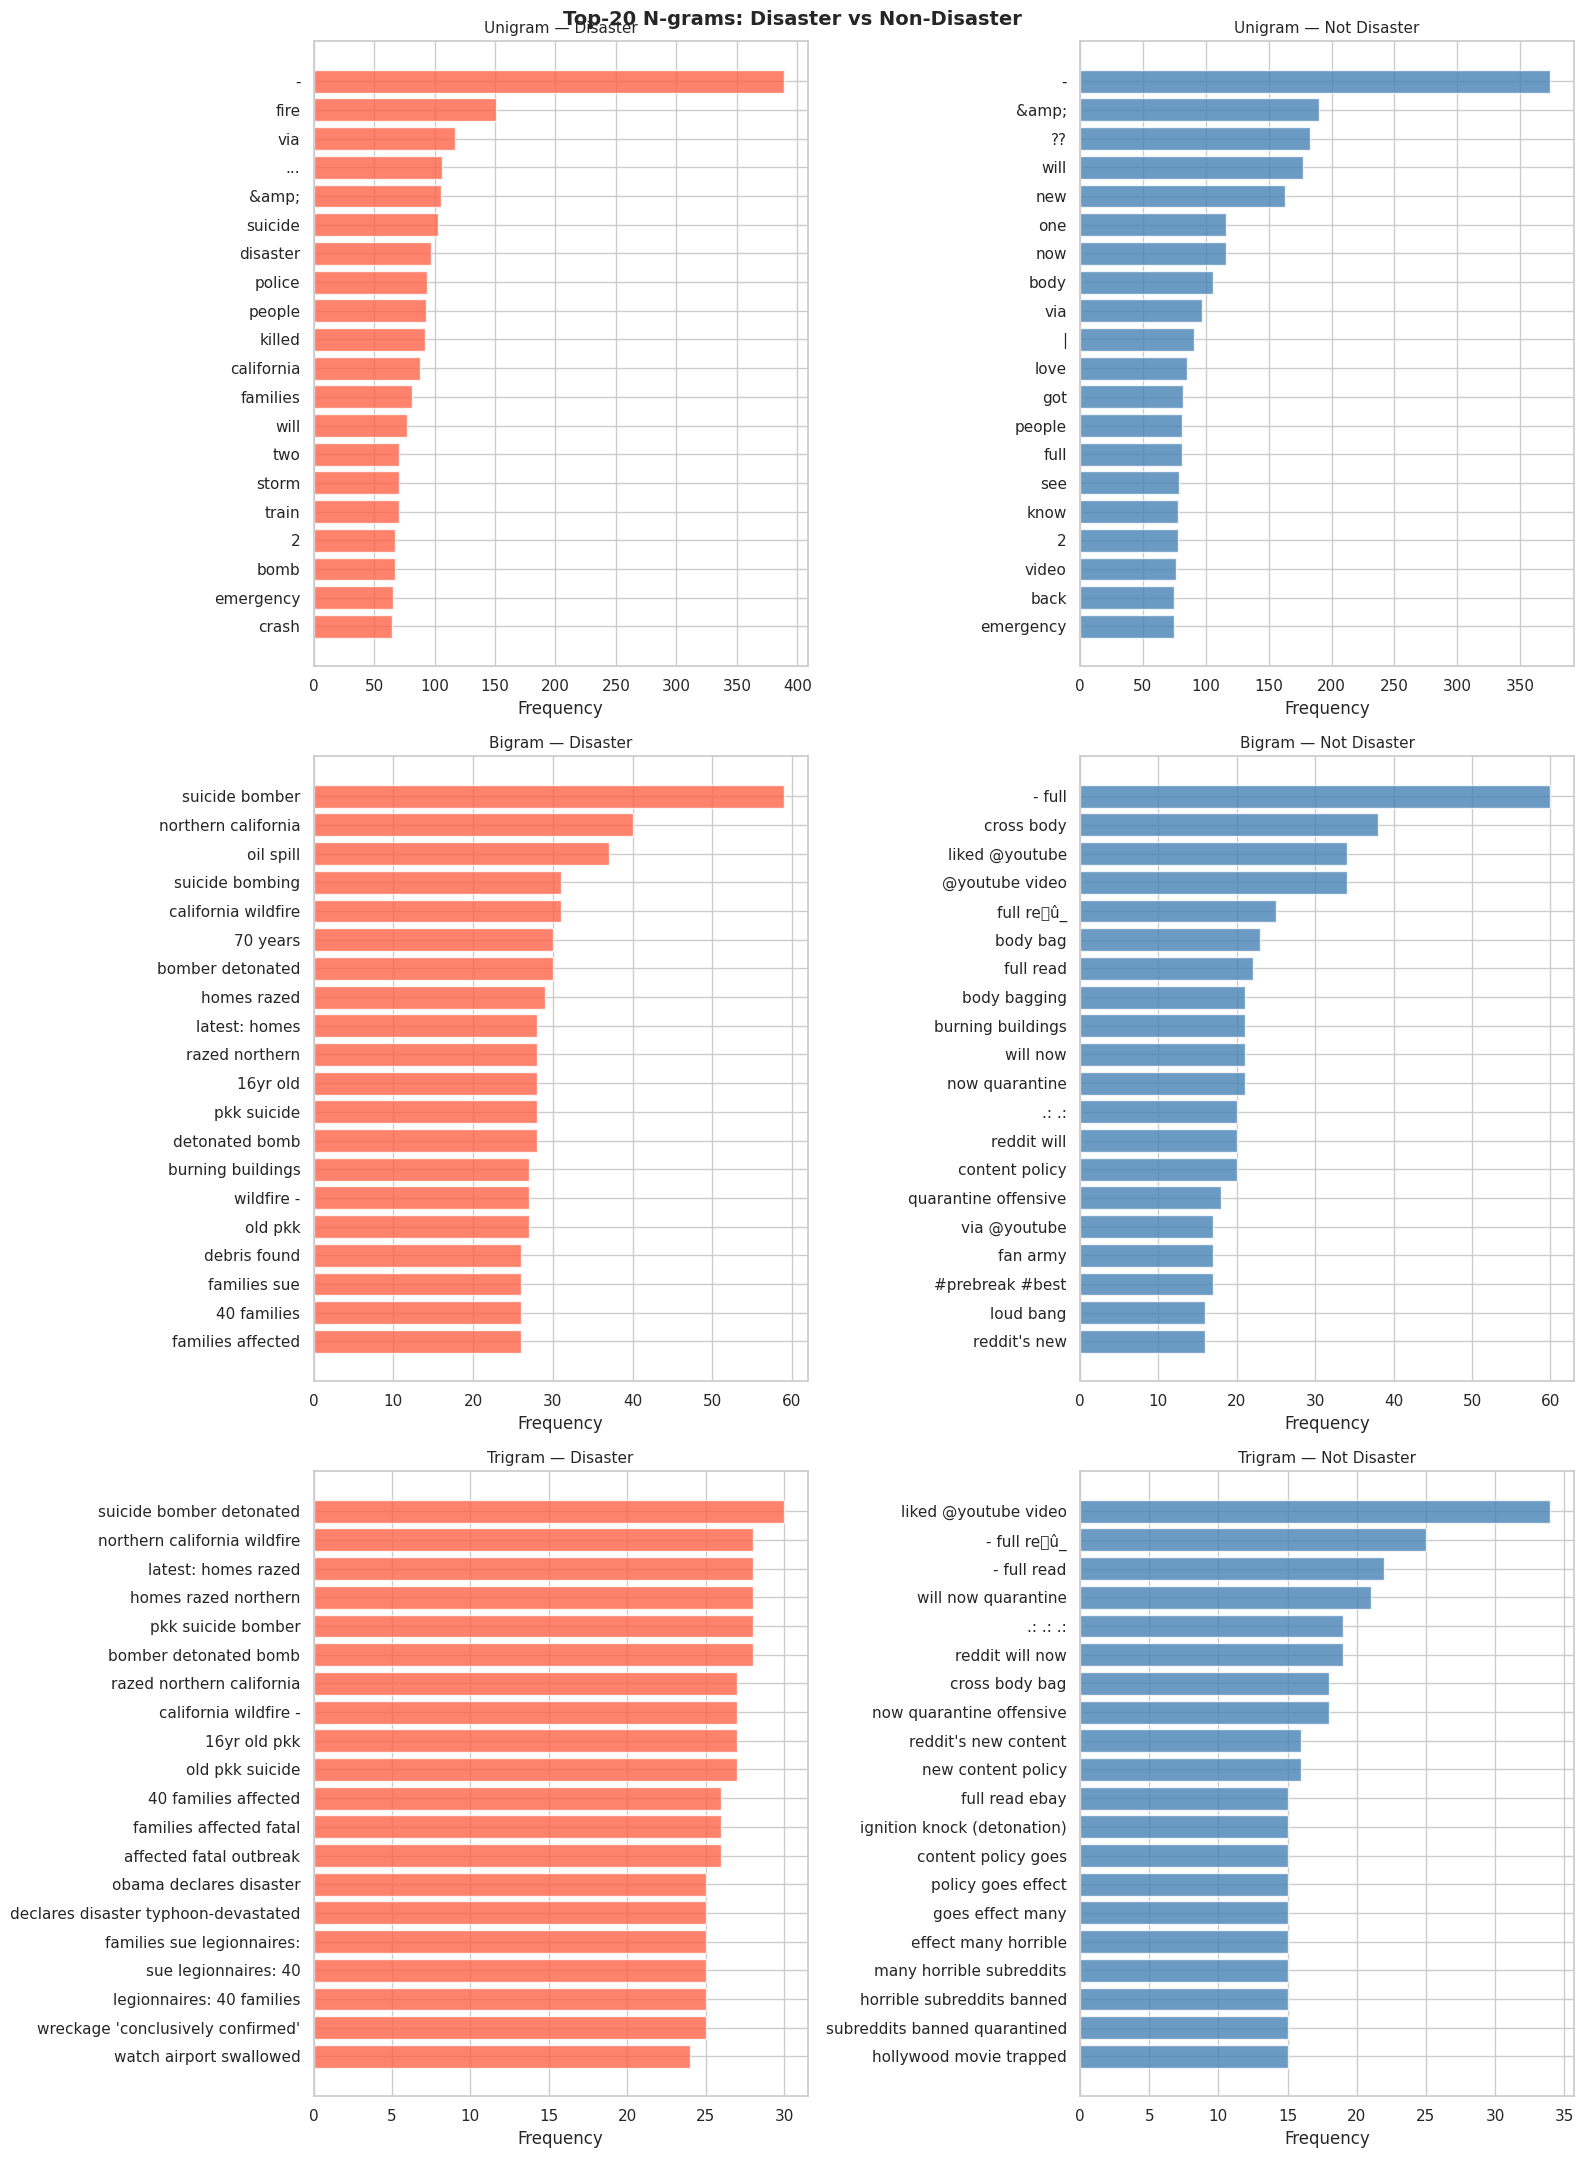

In [11]:
n_labels = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram'}

fig, axes = plt.subplots(3, 2, figsize=(16, 22))
fig.suptitle(f'Top-{TOP_N} N-grams: Disaster vs Non-Disaster', fontsize=14, fontweight='bold')

for row, n in enumerate([1, 2, 3]):
    for col, (key, color, label) in enumerate([
        ('disaster',    'tomato',    'Disaster'),
        ('nondisaster', 'steelblue', 'Not Disaster'),
    ]):
        df_ng = ngram_data[n][key].head(TOP_N)
        axes[row][col].barh(df_ng['ngram'][::-1], df_ng['count'][::-1], color=color, alpha=0.8)
        axes[row][col].set_title(f'{n_labels[n]} — {label}', fontsize=11)
        axes[row][col].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


## 5. OOF 에러 분석 (RoBERTa) <a id='5'></a>

K-Fold Cross-Validation으로 학습된 RoBERTa 모델의 **Out-of-Fold(OOF) 예측 결과**를 분석합니다.  
고확신 오답을 수동으로 검토하여 **노이즈 레이블**을 식별하고 데이터 품질을 개선합니다.

| 컬럼 | 설명 |
|------|------|
| `oof_prob` | 재난(1)으로 예측한 확률 |
| `oof_pred` | 이진 예측값 |
| `confidence` | `max(prob, 1-prob)` — 모델의 확신도 |
| `correct` | 정답 여부 |


In [12]:
# OOF 결과 로드
OOF_CSV = BASE_PATH + '/exp/exp13_kfold_roberta_oof/oof_result.csv'
oof_df  = pd.read_csv(OOF_CSV)

print(f'OOF 데이터: {oof_df.shape}')
print(f'전체 정확도: {oof_df["correct"].mean():.4f}')
oof_df.head()


OOF 데이터: (7613, 9)
전체 정확도: 0.8317


,id,keyword,location,text,target,oof_prob,oof_pred,correct,confidence
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,0.584790,1.0,True,0.584790
1,4,NaN,NaN,Forest fire near La Ronge Sask . Canada,1,0.993077,1.0,True,0.993077
2,5,NaN,NaN,All residents asked to ' shelter in place ' ar...,1,0.886064,1.0,True,0.886064
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,0.995270,1.0,True,0.995270
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,0.983151,1.0,True,0.983151


In [13]:
# 고확신 오답 추출 (confidence >= 0.9 & 오답)
high_conf_wrong = (
    oof_df[~oof_df['correct'] & (oof_df['confidence'] >= 0.9)]
    .sort_values('confidence', ascending=False)
)

print(f'고확신 오답 (confidence ≥ 0.9): {len(high_conf_wrong)}개')
high_conf_wrong[['text', 'target', 'oof_prob', 'oof_pred', 'confidence']].head(20)


고확신 오답 (confidence ≥ 0.9): 144개


,text,target,oof_prob,oof_pred,confidence
1186,Ashes 2015 : Australia  Ûªs collapse at Trent...,0,0.991921,1.0,0.991921
5641,wowo - - = = = 12000 Nigerian refugees repatri...,0,0.989486,1.0,0.989486
6042,ENGLAND EAST COAST . Dogger Bank Westward . 1 ...,0,0.989382,1.0,0.989382
4336,Patience Jonathan On The Move To Hijack APC In...,0,0.988323,1.0,0.988323
2877,Large rain drops falling in Rock Hill off Ande...,0,0.988186,1.0,0.988186
7043,Satellite Spies Super Typhoon Soudelor from Sp...,0,0.986492,1.0,0.986492
2832,. POTUS #StrategicPatience is a strategy for #...,0,0.986140,1.0,0.986140
3343,Trafford Centre film fans angry after Odeon ci...,0,0.985873,1.0,0.985873
2213,It 's a deluge in Trois-Rivieres . About one h...,0,0.984570,1.0,0.984570
2763,We have n't seen the devastation from the 2014...,0,0.982971,1.0,0.982971


### 5.1 노이즈 레이블 식별

고확신 오답을 수동 검토한 결과, 실제 레이블이 잘못 부여된 샘플을 아래 범주로 분류했습니다.

| 범주 | 예시 |
|------|------|
| 스포츠/크리켓 | "wicket", "hat trick" 등 스포츠 용어 |
| 비유적 표현 | "I'm dying" 등 관용적 표현 |
| 상품/광고 | 재난 키워드가 포함된 상품명 |
| 훈련/시뮬레이션 | 실제 재난이 아닌 훈련 상황 |


In [14]:
# 노이즈 레이블로 판단된 인덱스 (수동 검토 결과)
NOISE_IDX = [
    # 스포츠/크리켓
    1186, 1178, 1190, 1966,
    # 비유적 표현
    6707, 4305, 1798, 5918, 1847, 1853, 1873, 6006, 719, 5805,
    2905, 7572, 214, 5332, 1822, 2324, 5172, 6108, 2847, 1100,
    1782, 2250, 2085, 2715, 7145, 2544, 1791, 5223, 4500, 6119,
    6967, 5194, 6239, 939, 4732, 2552, 5387, 3728, 358, 1277,
    4734, 4143, 6514, 2738, 5973, 6011, 819, 2746, 412, 3663,
    4497, 6324, 5596, 3321, 6221, 7220,
    # 상품/광고
    974, 6317, 3797, 6213, 3441, 7481, 466, 3838,
    # 훈련/시뮬레이션
    1541, 7330,
    # 레이블 오류 (재난 없음)
    4055, 3954, 4227, 4522, 748, 2260, 2236, 789, 991,
    4661, 4665, 6160, 2556, 7144,
]

print(f'노이즈 레이블 후보: {len(NOISE_IDX)}개')
high_conf_wrong.loc[
    high_conf_wrong.index.isin(NOISE_IDX),
    ['text', 'target', 'confidence']
].sort_values('confidence', ascending=False)


노이즈 레이블 후보: 84개


,text,target,confidence
1186,Ashes 2015 : Australia  Ûªs collapse at Trent...,0,0.991921
1541,Google Alert : Emergency units simulate a chem...,0,0.980919
4522,Stream HYPE HURRICANE,0,0.976992
6213,[ 55436 ] 1950 LIONEL TRAINS SMOKE LOCOMOTIVES...,0,0.976622
4055,Tales of the #trees #deep water loving #Lake T...,0,0.973277
...,...,...,...
939,Even though BSG had been sufficiently hyped up...,1,0.901079
6967,and i dont get waves of missing you anymore th...,1,0.900959
5194,Drunk Meals 101 : What To Cook When You 're To...,1,0.900790
1277,burned 129 calories doing 24 minutes of Walkin...,1,0.900783


In [15]:
# 고확신 오답 결과 저장
SAVE_DIR = BASE_PATH + '/exp/exp13_kfold_roberta_oof'
high_conf_wrong.to_csv(f'{SAVE_DIR}/high_conf_wrong.csv', index=False)
print('저장 완료:', f'{SAVE_DIR}/high_conf_wrong.csv')


저장 완료: /content/drive/MyDrive/JM/ai-스터디/transformer/nlp-Disaster_Tweets-kaggle/exp/exp13_kfold_roberta_oof/high_conf_wrong.csv


### 5.2 Confidence 분포 분석


/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/3891205211.py:38: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

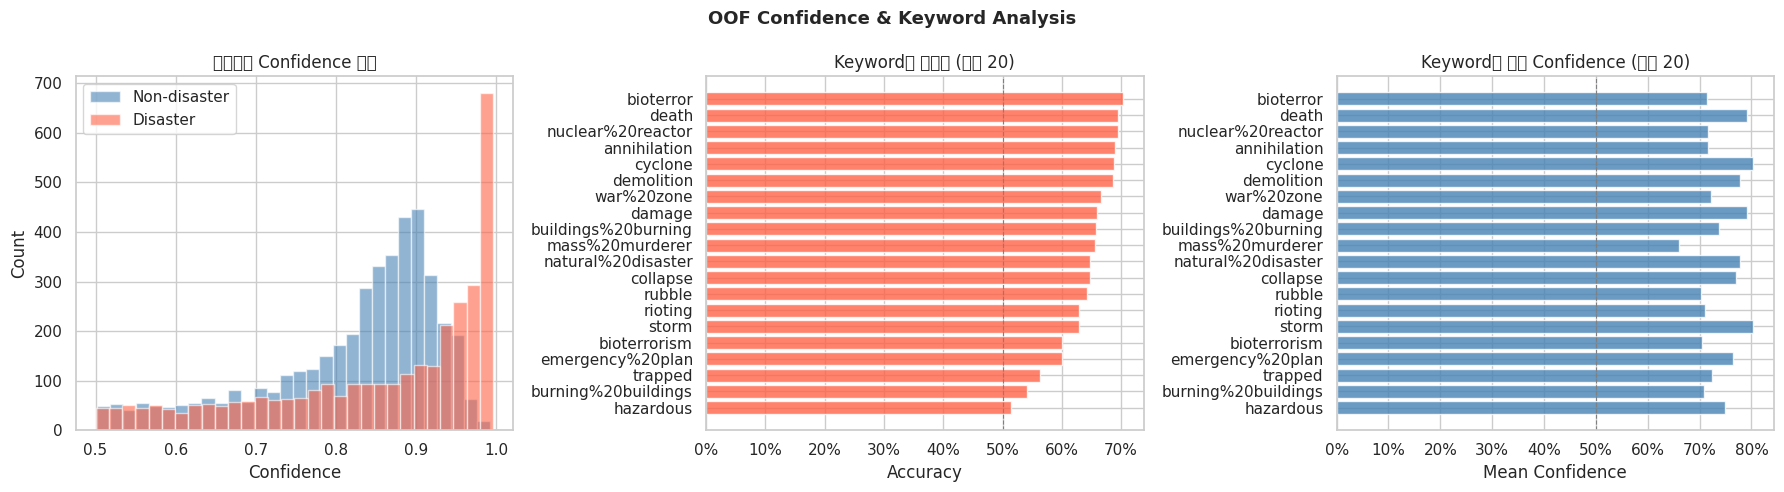

In [16]:
df = oof_df.copy()

# keyword별 성능 집계 (샘플 수 10개 이상)
kw_stats = (
    df[df['keyword'].notna()]
    .groupby('keyword')
    .agg(count=('correct', 'count'), accuracy=('correct', 'mean'), mean_conf=('confidence', 'mean'))
    .query('count >= 10')
    .sort_values('accuracy')
)
kw_bottom20 = kw_stats.head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OOF Confidence & Keyword Analysis', fontsize=13, fontweight='bold')

# ① 클래스별 confidence 분포
for target, label, color in [(0, 'Non-disaster', 'steelblue'), (1, 'Disaster', 'tomato')]:
    axes[0].hist(df[df['target'] == target]['confidence'], bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title('클래스별 Confidence 분포')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].legend()

# ② keyword별 정확도 하위 20
axes[1].barh(kw_bottom20.index, kw_bottom20['accuracy'], color='tomato', alpha=0.8)
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Keyword별 정확도 (하위 20)')
axes[1].set_xlabel('Accuracy')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# ③ keyword별 평균 confidence 하위 20
axes[2].barh(kw_bottom20.index, kw_bottom20['mean_conf'], color='steelblue', alpha=0.8)
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Keyword별 평균 Confidence (하위 20)')
axes[2].set_xlabel('Mean Confidence')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()


### 5.3 저확신 샘플 & 오답 패턴 분석


In [17]:
# 저확신 샘플 (모델이 애매하게 예측한 것)
low_conf = (
    df[df['confidence'] <= 0.6]
    .sort_values('confidence')
)
print(f'저확신 샘플 (confidence ≤ 0.6): {len(low_conf)}개')
low_conf[['text', 'target', 'oof_prob', 'oof_pred', 'confidence']].head(10)


저확신 샘플 (confidence ≤ 0.6): 573개


,text,target,oof_prob,oof_pred,confidence
73,BigRigRadio Live Accident Awareness,1,0.500091,1.0,0.500091
932,' If a truckload of soldiers will be blown up ...,1,0.499553,0.0,0.500447
1220,Sinking ships burning buildings & Falling obje...,1,0.499530,0.0,0.500470
1640,... The pain of those seconds must have been a...,1,0.499001,0.0,0.500999
4134,Grow Calgary avoids worst of city 's wicked we...,1,0.498851,0.0,0.501149
4687,11:30 BST traffic : A10 > Paris A40 Geneva A7 ...,1,0.501290,1.0,0.501290
6824,Hollywood movie about trapped miners released ...,0,0.498707,0.0,0.501293
1423,Warfighting Robots Could Reduce Civilian Casua...,1,0.498678,0.0,0.501322
1973,HIS MAJESTY EMPEROR SALMAN KHAN'S UNSTOPPABLE ...,0,0.501482,1.0,0.501482
4041,Q : Why do ducks have big flat feet ? A : To s...,0,0.501495,1.0,0.501495


/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_925/769598830.py:21: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

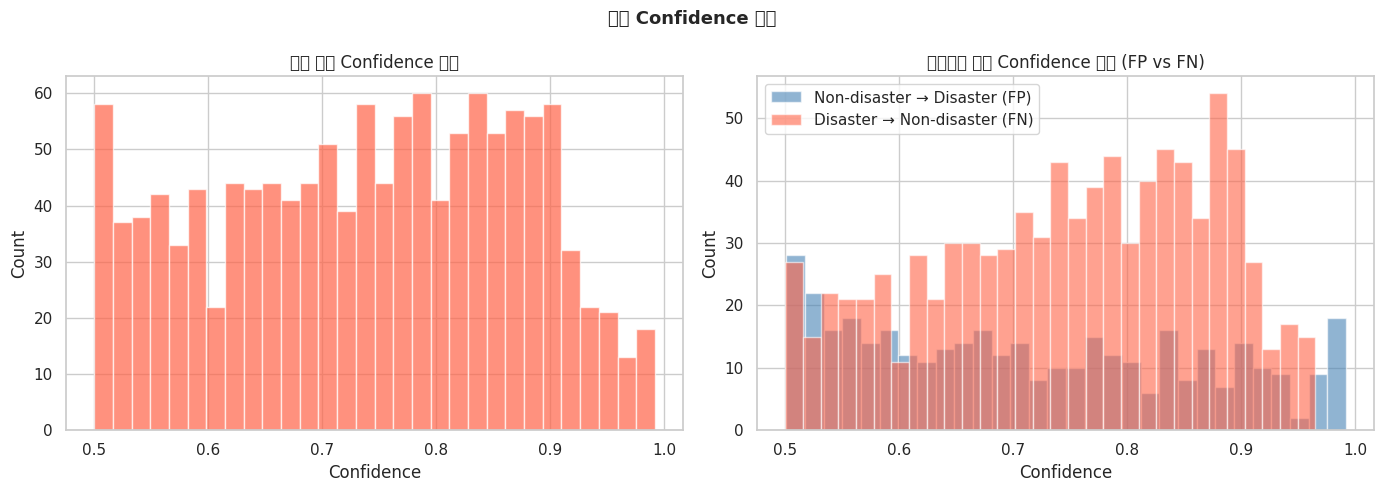


[Confidence 구간별 오답 수 (FP / FN)]
target    FP (Not Disaster)  FN (Disaster)
conf_bin                                  
0.5~0.6                 114            138
0.6~0.7                  82            165
0.7~0.8                  68            242
0.8~0.9                  62            266
0.9~1.0                  58             86


In [18]:
wrong = df[~df['correct']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('오답 Confidence 분포', fontsize=13, fontweight='bold')

# ① 전체 오답 confidence
axes[0].hist(wrong['confidence'], bins=30, color='tomato', alpha=0.7)
axes[0].set_title('오답 전체 Confidence 분포')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')

# ② FP / FN 비교
for target, label, color in [(0, 'Non-disaster → Disaster (FP)', 'steelblue'), (1, 'Disaster → Non-disaster (FN)', 'tomato')]:
    axes[1].hist(wrong[wrong['target'] == target]['confidence'],
                 bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title('클래스별 오답 Confidence 분포 (FP vs FN)')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Confidence 구간별 오답 수
bins   = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.5~0.6', '0.6~0.7', '0.7~0.8', '0.8~0.9', '0.9~1.0']
wrong = wrong.copy()
wrong['conf_bin'] = pd.cut(wrong['confidence'], bins=bins, labels=labels)
print('\n[Confidence 구간별 오답 수 (FP / FN)]')
print(wrong.groupby(['conf_bin', 'target'], observed=True).size().unstack(fill_value=0)
      .rename(columns={0: 'FP (Not Disaster)', 1: 'FN (Disaster)'}))


---
## 📝 분석 요약

| 항목 | 내용 |
|------|------|
| 데이터셋 | Train 7,613건 / Test 3,263건 |
| 클래스 분포 | Not Disaster 57% / Disaster 43% — 거의 균등 |
| 유의미한 메타 특징 | word_count, char_count, mean_word_length, punctuation_count |
| 고확신 오답 | 약 82개 → 노이즈 레이블 후보로 수동 검토 |
| 주요 오류 패턴 | 비유적 표현, 스포츠 은어, 상품/광고성 텍스트 |

**다음 단계:** 노이즈 레이블 제거 후 RoBERTa 재학습 → F1 스코어 개선 기대
